In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [4]:
iris = load_iris(as_frame=True)
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)
print(x.shape)
print("train:", x_train.shape, "test:", x_test.shape)

(150, 4)
train: (105, 4) test: (45, 4)


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle= True, random_state=42)


In [7]:
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

depth:  5 leaves:  8
train accuracy:  1.0
cv accuracy:  0.933


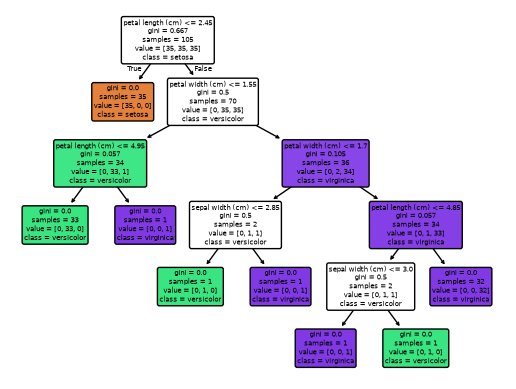

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

print("depth: ", dt.get_depth(), "leaves: ", dt.get_n_leaves())
print("train accuracy: ", dt.score(x_train, y_train))
print("cv accuracy: ", cross_val_score(dt, x_train, y_train, cv=cv).mean().round(3))

plot_tree(dt, feature_names= x.columns, class_names=iris.target_names, filled=True, rounded=True)
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

print("train accuracy: ", rf.score(x_train, y_train))

print("cv accuracy: ", cross_val_score(rf, x_train, y_train, cv=cv).mean().round(3))

train accuracy:  1.0
cv accuracy:  0.952


In [13]:
## svm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ('svc', SVC(random_state=42))
])

svm.fit(x_train, y_train)
print("train accuracy: ", round(svm.score(x_train, y_train), 3))
print("cv accuracy: ", cross_val_score(rf, x_train, y_train, cv=cv).mean().round(3))
print("support vector per class", svm.named_steps["svc"].n_support_)

train accuracy:  0.971
cv accuracy:  0.952
support vector per class [ 6 18 16]
